# Objetivo do trabalho
Uso do alexNet para detecção de cancer de intestino
- Dateset: LC25000
- 5000 imagens de não cancer
- 5000 imagens de cancer
- Dataset CRC5000
- resolução transformadas: 150 x 150 pixeis

In [1]:
import tqdm
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import kagglehub
import shutil
from typing import Tuple
from PIL import Image
from imblearn.combine import SMOTETomek
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
import os
import datetime
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tabulate import tabulate
import seaborn as sns
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")

Using: NVIDIA A100-SXM4-40GB
CUDA: 12.6


In [3]:

path = kagglehub.dataset_download("kmader/colorectal-histology-mnist")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000


100%|██████████| 1.90G/1.90G [00:12<00:00, 161MB/s] 

Extracting files...


01_TUMOR   03_COMPLEX  05_DEBRIS  07_ADIPOSE
02_STROMA  04_LYMPHO   06_MUCOSA  08_EMPTY


In [4]:
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls lung_colon_image_set

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
colon_image_sets  lung_image_sets


In [14]:
def generate_crc_csv(path):
    path_to_dataset = pathlib.Path(path)
    CRC5000Formatter(input_path = path_to_dataset, output_csv = "nb_crc5000.csv").run()


def generate_lc_csv(path):
    path_to_dataset = pathlib.Path(path)
    LC25000Formatter(input_path = path_to_dataset, output_csv = "nb_lc25000.csv").run()


def get_formatted_both_datasets():
    generate_crc_csv("/content/Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000")
    generate_lc_csv("/content/lung_colon_image_set/colon_image_sets")

    dataframe_crc = pd.read_csv("/content/nb_crc5000.csv")
    dataframe_lc = pd.read_csv("/content/nb_lc25000.csv")

    x_train, x_validation, y_train, y_validation = train_test_split(
    dataframe_lc["path"],
    dataframe_lc["label"],
    test_size=0.2,
    random_state=42,
    stratify=dataframe_lc["label"]
    )

    df_train = pd.DataFrame({"path": x_train, "label": y_train})
    df_validation = pd.DataFrame({"path": x_validation, "label": y_validation})
    
    x_test = dataframe_crc["path"]
    y_test = dataframe_crc["label"]

    df_test = pd.DataFrame({"path": x_test, "label": y_test})  

    return df_train, df_validation, df_test

class CRC5000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "01_TUMOR": int(1),
            "06_MUCOSA": int(0),
            "07_ADIPOSE": int(0),
            "08_EMPTY": int(0),
        }
        image_extensions = ['.tif', '.tiff']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                if label not in label_map:
                    continue
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df
    
class LC25000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "colon_n": int(0),
            "colon_aca": int(1)
        }
        image_extensions = ['.jpg', '.jpeg', '.png']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df

In [15]:
df_train, df_validation, df_test = get_formatted_both_datasets()
print(f"\nNumber of images in training dataset: {len(df_train)}")
print(f"Number of images in validation dataset: {len(df_validation)}")
print(f"Number of images in test dataset: {len(df_test)}")

100%|██████████| 5008/5008 [00:00<00:00, 40415.13it/s]


CSV salvo com sucesso em: nb_crc5000.csv


100%|██████████| 10002/10002 [00:00<00:00, 25438.46it/s]


CSV salvo com sucesso em: nb_lc25000.csv

Number of images in training dataset: 8000
Number of images in validation dataset: 2000
Number of images in test dataset: 2500


In [16]:
class CRC5000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]
    
class CRC5000DatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


class LC25000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


class LC25000DatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(150, 150),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(150, 150),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])



def get_dataloaders(df_train, df_validation, df_test, batch_size = 1, num_workers = 0):
    dataset_train = LC25000DatasetMemory(
        df_train,
        transforms=LC25000DatasetConfig.TRAIN_TRANSFORMS,
        target_column="label",
    )

    dataset_validation = LC25000DatasetMemory(
        df_validation,
        transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
        target_column="label",
    )

    dataset_test = CRC5000DatasetMemory(
        df_test,
        transforms=CRC5000DatasetConfig.TEST_TRANSFORMS,
        target_column="label",
    )

    dataloader_train = DataLoader(dataset_train, batch_size= batch_size,pin_memory = True, shuffle= True, num_workers = num_workers)
    dataloader_validation = DataLoader(dataset_validation, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)
    dataloader_test = DataLoader(dataset_test, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)

    return dataloader_train, dataloader_validation, dataloader_test

In [17]:
batch_size = 64
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test, batch_size, 2)

### hiperparametros
- numero de canais de entrada: 3
- numero de classes de saída: 2
- taxa de aprendizado: 1e-4
- otimizador: Adam
- número de épocas: 50

In [18]:
in_channels = 3
output_features = 2
learning_rate = 1e-4

In [19]:
model = torchvision.models.alexnet(num_classes=output_features)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


### Treinamento

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
criterion = torch.nn.CrossEntropyLoss()

def train_model(model, dataloader_train, dataloader_validation, optimizer, epochs = 10, patience = 0, scheduler = None, drive_path = '/content/drive/MyDrive/Machine Learning/Resultados TCC/models/LC25000+CRC5000/Adam/normal'):
    model = model.to("cuda")
    device = "cuda"
    train_losses = []
    val_losses = []
    best_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_loss_validation = 0

        for images, labels in dataloader_train:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size()[0]

        with torch.no_grad():
            model.eval() 

            for images, labels in dataloader_validation:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss_validation += loss.item() * images.size()[0]
            

        avg_train_loss = total_loss / len(dataloader_train.dataset)
        avg_val_loss = total_loss_validation / len(dataloader_validation.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if scheduler is not None:
            scheduler.step()

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"{model.__class__.__name__}.pt")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        if patience > 0 and epochs_no_improve >= patience:
            print(f"\nEarly stopping ativado! Melhor Val Loss: {best_loss:.4f}")
            break
    
    model.load_state_dict(best_model_state)
    os.makedirs(drive_path, exist_ok=True)
    best_path = drive_path + f"/{model.__class__.__name__}_best.pt"
    torch.save(best_model_state, best_path)
    return train_losses, val_losses, model

def test_model(model, device, dataloader_test):
    model = model.to(device)
    model.eval()  # Modo de avaliação
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader_test:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Cálculo das métricas
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-score (weighted): {f1:.4f}")
    print("Matriz de Confusão:")
    print(cm)

    return acc, precision, recall, f1, cm


In [22]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50, 15)

Epoch 1/50 | Train Loss: 0.4887 | Val Loss: 0.3732
Epoch 2/50 | Train Loss: 0.2551 | Val Loss: 0.1011
Epoch 3/50 | Train Loss: 0.1061 | Val Loss: 0.0449
Epoch 4/50 | Train Loss: 0.0750 | Val Loss: 0.0845
Epoch 5/50 | Train Loss: 0.0449 | Val Loss: 0.0244
Epoch 6/50 | Train Loss: 0.0479 | Val Loss: 0.0230
Epoch 7/50 | Train Loss: 0.0214 | Val Loss: 0.0292
Epoch 8/50 | Train Loss: 0.0180 | Val Loss: 0.0503
Epoch 9/50 | Train Loss: 0.0039 | Val Loss: 0.0219
Epoch 10/50 | Train Loss: 0.0094 | Val Loss: 0.0315
Epoch 11/50 | Train Loss: 0.0159 | Val Loss: 0.0247
Epoch 12/50 | Train Loss: 0.0048 | Val Loss: 0.0087
Epoch 13/50 | Train Loss: 0.0124 | Val Loss: 0.0203
Epoch 14/50 | Train Loss: 0.0310 | Val Loss: 0.0181
Epoch 15/50 | Train Loss: 0.0015 | Val Loss: 0.0226
Epoch 16/50 | Train Loss: 0.0140 | Val Loss: 0.0174
Epoch 17/50 | Train Loss: 0.0028 | Val Loss: 0.0155
Epoch 18/50 | Train Loss: 0.0147 | Val Loss: 0.0297
Epoch 19/50 | Train Loss: 0.0012 | Val Loss: 0.0129
Epoch 20/50 | Train L

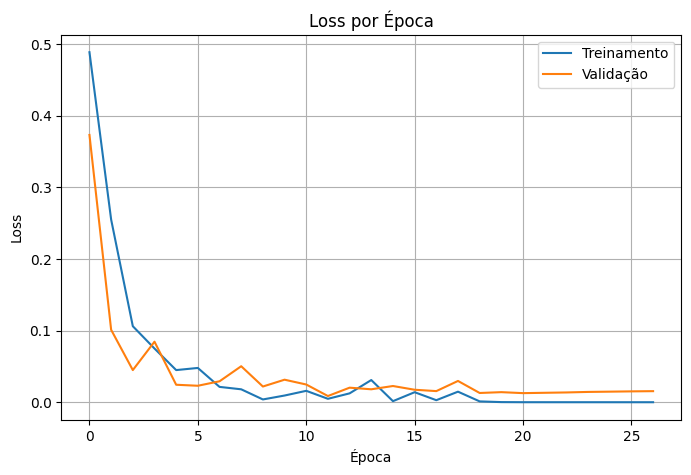

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test)

Acurácia: 0.3364
Precisão (weighted): 0.8184
Recall (weighted): 0.3364
F1-score (weighted): 0.2624
Matriz de Confusão:
[[ 216 1659]
 [   0  625]]


In [25]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.3364 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.8184 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.3364 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.2624 │
╘═════════════════════╧═════════╛


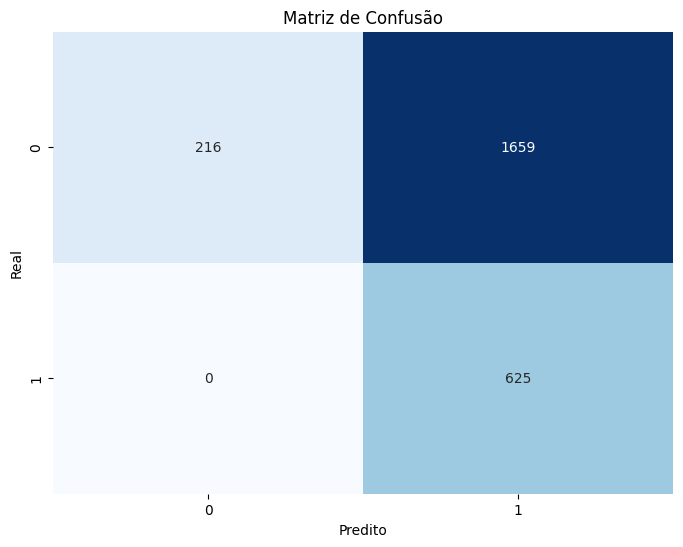

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()